In [1]:
!pip install gurobipy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\simor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2 – Model extensions on the 100 bricks / 10 SRs instance


### 2.1 100 bricks / 10 SRs – computing the non‑dominated set (integral assignments)

In this section we:
- load the 100×10 instance from the Excel file,
- rebuild the distance matrix and the current territories from the raw data,
- reuse the same workload‑balance constraints as in Step 1,
- compute the non‑dominated set for the bi‑objective problem  
  (minimize distance, minimize disruption) using an ε‑constraint scheme.


Total workload after scaling: 10.0000 (target = 10)
Office indices (0‑based): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape (SRs × bricks): (10, 100)

=== 2.1 100 bricks / 10 SRs – integral assignments (x ∈ {0,1}) ===
Restricted license - for non-production use only - expires 2026-11-23
Disruption at minimal distance: 4.8015
Minimal achievable disruption: 0.3427
ε-grid: [0.3427 0.4427 0.5427 0.6427 0.7427 0.8427 0.9427 1.0427 1.1427 1.2427
 1.3427 1.4427 1.5427 1.6427 1.7427 1.8427 1.9427 2.0427 2.1427 2.2427
 2.3427 2.4427 2.5427 2.6427 2.7427 2.8427 2.9427 3.0427 3.1427 3.2427
 3.3427 3.4427 3.5427 3.6427 3.7427 3.8427 3.9427 4.0427 4.1427 4.2427
 4.3427 4.4427 4.5427 4.6427 4.7427]
ε = 0.3427  →  distance = 27.379, disruption = 0.3427
ε = 0.4427  →  distance = 25.301, disruption = 0.4287
ε = 0.5427  →  distance = 24.276, disruption = 0.5360
ε = 0.6427  →  distance = 23.738, disruption = 0.6354
ε = 0.7427  →  distance = 23.098, disruption = 0.7386
ε = 0.8427  →  dista

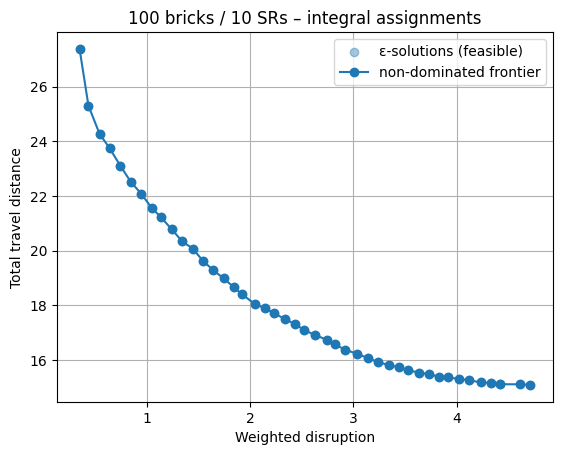

In [2]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from gurobipy import Model, GRB

# ---------------------------------------------------------------------------
# Data loading and preprocessing
# ---------------------------------------------------------------------------

CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR / "data-100x10.xlsx"

# The Excel file contains, for each brick:
#  - x, y       : geographical coordinates
#  - index      : workload index
#  - current    : id of the currently responsible SR
#  - office     : 1 if the brick hosts an SR office, 0 otherwise
df = pd.read_excel(
    DATA_PATH,
    header=None,
    usecols="A:E",
    nrows=100
)
df.columns = ["x", "y", "index", "current", "office"]

Bricks = len(df)

# Number of sales reps = number of offices in the file
Sales = int(df["office"].sum())

# Raw workload indices from the file
workloads_raw = df["index"].to_numpy(dtype=float)

# In the original 4×22 instance, the sum of the indices was equal to the
# number of SRs. We keep the same convention here by rescaling the indices
# so that the total workload equals the number of SRs.
scale = Sales / workloads_raw.sum()
workloads = workloads_raw * scale
print(f"Total workload after scaling: {workloads.sum():.4f} (target = {Sales})")

# Coordinates of all bricks
coords = df[["x", "y"]].to_numpy(dtype=float)

# Indices of bricks that host an SR office (0-based)
office_indices = df.index[df["office"] == 1].to_list()
assert len(office_indices) == Sales, "Office count must match the number of SRs"
print(f"Office indices (0‑based): {office_indices}")

# Distance[j, i] = distance between office of SR j and brick i.
# We build SR j in the same order as office_indices.
Distance = np.vstack([
    np.linalg.norm(coords - coords[office_idx], axis=1)
    for office_idx in office_indices
])
print("Distance matrix shape (SRs × bricks):", Distance.shape)

# Initial (current) assignment matrix:
#   SR_initial[j, i] = 1 if brick i currently belongs to SR j, 0 otherwise.
SR_initial = np.zeros((Sales, Bricks), dtype=int)
for i in range(Bricks):
    sr = int(df.loc[i, "current"]) - 1  # data is 1‑based
    if 0 <= sr < Sales:
        SR_initial[sr, i] = 1

# Workload bounds as in the project statement
WORKLOAD_BOUNDS = (0.8, 1.2)


# ---------------------------------------------------------------------------
# Model builder
# ---------------------------------------------------------------------------

def build_assignment_model(
    vtype=GRB.BINARY,
    workloads=workloads,
    distance=Distance,
    initial_assignment=SR_initial,
    workload_bounds=WORKLOAD_BOUNDS,
    model_name="Pfizer_100x10",
):
    """Build a Gurobi model for the assignment problem.

    Parameters
    ----------
    vtype : gurobipy constant
        GRB.BINARY (default) for integral assignments or GRB.CONTINUOUS
        for partial assignments.
    workloads : np.ndarray
        Workload index of each brick (length = number of bricks).
    distance : np.ndarray
        Matrix of shape (Sales, Bricks) with travel distances.
    initial_assignment : np.ndarray
        0/1 matrix of shape (Sales, Bricks) describing the current territories.
    workload_bounds : (float, float)
        Lower and upper bounds on each SR's workload.
    model_name : str
        Name of the Gurobi model.

    Returns
    -------
    m : gurobipy.Model
    x : gurobipy.tupledict
        Decision variables x[j, i] (fraction of brick i assigned to SR j).
    distance_expr : gurobipy.LinExpr
        Expression for the total traveled distance.
    disruption_expr : gurobipy.LinExpr
        Expression for the (workload‑weighted) disruption.
    """
    m = Model(model_name)
    m.Params.OutputFlag = 0  # keep the log clean

    sales, bricks = distance.shape

    # x[j, i] is the fraction of brick i served by SR j.
    x = m.addVars(sales, bricks, vtype=vtype, name="x")

    # (1) Coverage: each brick must be entirely covered
    for i in range(bricks):
        m.addConstr(sum(x[j, i] for j in range(sales)) == 1.0, name=f"assign_{i}")

    # (2) Workload balance: each SR workload in [min_w, max_w]
    min_w, max_w = workload_bounds
    for j in range(sales):
        load = sum(x[j, i] * workloads[i] for i in range(bricks))
        m.addConstr(load >= min_w, name=f"load_min_{j}")
        m.addConstr(load <= max_w, name=f"load_max_{j}")

    # (3) Total distance
    distance_expr = sum(
        distance[j, i] * x[j, i] for j in range(sales) for i in range(bricks)
    )

    # (4) Disruption, weighted by workload:
    #     if a brick changes SR, we incur its workload as disruption.
    disruption_expr = sum(
        0.5
        * (initial_assignment[j, i] - 2 * initial_assignment[j, i] * x[j, i] + x[j, i])
        * workloads[i]
        for j in range(sales)
        for i in range(bricks)
    )

    return m, x, distance_expr, disruption_expr


# ---------------------------------------------------------------------------
# ε‑constraint scheme (distance as main objective, disruption constrained)
# ---------------------------------------------------------------------------

def epsilon_pareto(vtype=GRB.BINARY):
    """Compute Pareto points with an ε‑constraint on the disruption.

    The function returns a list of (disruption, distance) points.
    """
    # 1) Distance‑only solution
    m_dist, _, dist_expr_dist, disr_expr_dist = build_assignment_model(vtype=vtype)
    m_dist.setObjective(dist_expr_dist, GRB.MINIMIZE)
    m_dist.optimize()
    if m_dist.status != GRB.OPTIMAL:
        raise RuntimeError("Distance‑only model is infeasible.")
    disr_at_min_dist = disr_expr_dist.getValue()
    print(f"Disruption at minimal distance: {disr_at_min_dist:.4f}")

    # 2) Disruption‑only solution
    m_disr, _, _, disr_expr_disr = build_assignment_model(vtype=vtype)
    m_disr.setObjective(disr_expr_disr, GRB.MINIMIZE)
    m_disr.optimize()
    if m_disr.status != GRB.OPTIMAL:
        raise RuntimeError("Disruption‑only model is infeasible.")
    disr_min = disr_expr_disr.getValue()
    print(f"Minimal achievable disruption: {disr_min:.4f}")

    lo, hi = sorted((disr_min, disr_at_min_dist))
    epsilon_step = 0.1   # Step of 0.1
    epsilons = np.arange(lo, hi + 1e-9, epsilon_step)
    print("ε-grid:", np.round(epsilons, 4))


    pareto = []
    for eps in epsilons:
        m, _, dist_expr, disr_expr = build_assignment_model(vtype=vtype)
        # ε‑constraint on disruption
        m.addConstr(disr_expr <= float(eps) + 1e-6, name="eps_disruption")
        m.setObjective(dist_expr, GRB.MINIMIZE)
        m.optimize()

        if m.status == GRB.OPTIMAL:
            d = dist_expr.getValue()
            r = disr_expr.getValue()
            pareto.append((r, d))
            print(f"ε = {eps:.4f}  →  distance = {d:.3f}, disruption = {r:.4f}")
        else:
            print(f"ε = {eps:.4f}  →  infeasible")

    return pareto


def non_dominated(points, tol=1e-6):
    """Extract non‑dominated points from a list of (disruption, distance)."""
    pts = sorted(points, key=lambda p: (p[0], p[1]))  # sort by disruption then distance
    nd = []
    best_dist = float("inf")
    for disr, dist in pts:
        if dist < best_dist - tol:
            nd.append((disr, dist))
            best_dist = dist
    return nd


# ---------------------------------------------------------------------------
# 2.1 – 100 bricks / 10 SRs with integral assignments
# ---------------------------------------------------------------------------

print("\n=== 2.1 100 bricks / 10 SRs – integral assignments (x ∈ {0,1}) ===")
pareto_int = epsilon_pareto(vtype=GRB.BINARY)
nd_int = non_dominated(pareto_int)

if nd_int:
    disr_all, dist_all = zip(*pareto_int)
    disr_nd, dist_nd = zip(*nd_int)

    plt.figure()
    plt.scatter(disr_all, dist_all, alpha=0.4, label="ε‑solutions (feasible)")
    plt.plot(disr_nd, dist_nd, "o-", label="non‑dominated frontier")
    plt.xlabel("Weighted disruption")
    plt.ylabel("Total travel distance")
    plt.title("100 bricks / 10 SRs – integral assignments")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No Pareto points found for the integral model.")



### 2.2 Allowing partial assignment of bricks

We now relax the integrality constraints and allow each brick to be **split between several SRs**
(i.e., the variables become continuous in \([0,1]\)).  
The model is exactly the same as above; only the variable type changes.
We then compare the Pareto front with the integral case.



=== 2.2 100 bricks / 10 SRs – partial assignments allowed (x ∈ [0,1]) ===
Disruption at minimal distance: 5.0104
Minimal achievable disruption: 0.3426
ε-grid: [0.3426 0.4426 0.5426 0.6426 0.7426 0.8426 0.9426 1.0426 1.1426 1.2426
 1.3426 1.4426 1.5426 1.6426 1.7426 1.8426 1.9426 2.0426 2.1426 2.2426
 2.3426 2.4426 2.5426 2.6426 2.7426 2.8426 2.9426 3.0426 3.1426 3.2426
 3.3426 3.4426 3.5426 3.6426 3.7426 3.8426 3.9426 4.0426 4.1426 4.2426
 4.3426 4.4426 4.5426 4.6426 4.7426 4.8426 4.9426]
ε = 0.3426  →  distance = 26.645, disruption = 0.3426
ε = 0.4426  →  distance = 24.910, disruption = 0.4426
ε = 0.5426  →  distance = 24.029, disruption = 0.5426
ε = 0.6426  →  distance = 23.420, disruption = 0.6426
ε = 0.7426  →  distance = 22.904, disruption = 0.7426
ε = 0.8426  →  distance = 22.425, disruption = 0.8426
ε = 0.9426  →  distance = 21.960, disruption = 0.9426
ε = 1.0426  →  distance = 21.502, disruption = 1.0426
ε = 1.1426  →  distance = 21.077, disruption = 1.1426
ε = 1.2426  →  dist

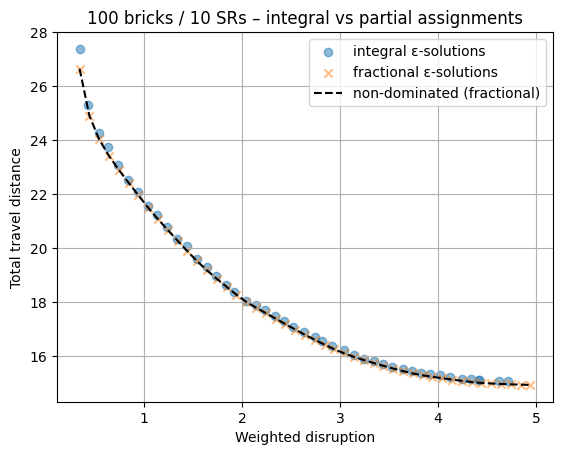

Minimal distance (integral model) : 15.082
Minimal distance (fractional model): 14.942


In [3]:

import matplotlib.pyplot as plt
from gurobipy import GRB

print("\n=== 2.2 100 bricks / 10 SRs – partial assignments allowed (x ∈ [0,1]) ===")

# Compute Pareto set with continuous variables
pareto_frac = epsilon_pareto(vtype=GRB.CONTINUOUS)
nd_frac = non_dominated(pareto_frac)

if pareto_frac and 'pareto_int' in globals():
    # Plot both sets on the same figure for an easy visual comparison
    disr_int, dist_int = zip(*pareto_int)
    disr_frac, dist_frac = zip(*pareto_frac)

    plt.figure()
    plt.scatter(disr_int, dist_int, alpha=0.5, label="integral ε‑solutions")
    plt.scatter(disr_frac, dist_frac, alpha=0.5, marker="x", label="fractional ε‑solutions")

    if nd_frac:
        disr_nd_f, dist_nd_f = zip(*nd_frac)
        plt.plot(disr_nd_f, dist_nd_f, "k--", label="non‑dominated (fractional)")

    plt.xlabel("Weighted disruption")
    plt.ylabel("Total travel distance")
    plt.title("100 bricks / 10 SRs – integral vs partial assignments")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Simple numeric comparison: best distance for low disruption levels
    best_int = min(dist_int)
    best_frac = min(dist_frac)
    print(f"Minimal distance (integral model) : {best_int:.3f}")
    print(f"Minimal distance (fractional model): {best_frac:.3f}")
else:
    print("Could not compute Pareto points for the fractional model.")



> **Remark.**  
> The continuous model is mainly a *theoretical* extension: in practice a brick is typically
> assigned to a single SR.  
> However, relaxing integrality is very helpful to understand the structure of the problem
> and to measure the gap between the fully integral solution and the (optimistic) case where
> bricks can be fractionally shared between several SRs.


### 2.3 Adding a new SR when demand increases by 25 %

We now suppose that the demand (workload index) in **all bricks increases by 25 %**.  
To cope with this extra workload, Pfizer decides to hire **one additional sales representative**.

We keep the same structure of the model, but:
- workloads are multiplied by 1.25,
- we add a new SR with its own office,
- and we let the model decide the *best brick* where this new office should be located,
  assuming it must coincide with one of the existing bricks.

Instead of testing each possible office location one by one, we formulate everything in a **single MILP**:

- we introduce binary variables indicating **where** the new SR’s office is located (which brick),
- we introduce assignment variables describing **which bricks** are served by each existing SR and by the new SR,
- we keep the **workload-balance constraints** for all SRs (old and new),
- we model the **disruption** as the set of bricks whose SR changes compared to the initial territories.

The objective is to **minimize the total travel distance** (existing SRs + new SR) under these constraints.  
Solving this single optimization model directly yields:

- the optimal brick where the new SR’s office should be placed,  
- the new assignment of bricks to SRs,  
- the corresponding total distance and disruption.


In [4]:
num_bricks = 22

###### --- Data ---
distances = [[16.16, 24.08, 24.32, 21.12], 
     [19, 26.47, 27.24, 17.33], 
     [25.29, 32.49, 33.42, 12.25], 
     [0, 7.93, 8.31, 36.12], 
     [3.07, 6.44, 7.56, 37.37], 
     [1.22, 7.51, 8.19, 36.29], 
     [2.80, 10.31, 10.95, 33.5], 
     [2.87, 5.07, 5.67, 38.8], 
     [3.8, 8.01, 7.41, 38.16], 
     [12.35, 4.52, 4.35, 48.27], 
     [11.11, 3.48, 2.97, 47.14], 
     [21.99, 22.02, 24.07, 39.86], 
     [8.82, 3.3, 5.36, 43.31], 
     [7.93, 0, 2.07, 43.75], 
     [9.34, 2.25, 1.11, 45.43], 
     [8.31, 2.07, 0, 44.43], 
     [7.31, 2.44, 1.11, 43.43], 
     [7.55, 0.75, 1.53, 43.52], 
     [11.13, 18.41, 19.26, 25.4], 
     [17.49, 23.44, 24.76, 23.21], 
     [11.03, 18.93, 19.28, 25.43], 
     [36.12, 43.75, 44.43, 0]] 

workloads = [0.1609, 0.1164, 0.1026, 0.1516, 0.0939, 
     0.1320, 0.0687, 0.0930, 0.2116, 0.2529, 
     0.0868, 0.0828, 0.0975, 0.8177, 0.4115, 
     0.3795, 0.0710, 0.0427, 0.1043, 0.0997, 
     0.1698, 0.2531]

## Initial state : 
SR1_center = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SR2_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
SR4_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

SR1_initial_state = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
SR2_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
SR4_initial_state = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
SRs = [SR1_initial_state, SR2_initial_state, SR3_initial_state, SR4_initial_state]



In [5]:
from gurobipy import Model, GRB, quicksum
import numpy as np

print("\n=== 2.3 Adding a new SR after a +25% demand increase (4x22 instance) ===")

# -----------------------------
# Data from the first cell
# -----------------------------
B = num_bricks              # 22 bricks
J_old = 4                   # 4 existing SRs

# Distance[j, i] = distance between SR j and brick i
# Your 'distances' is list of 22 rows (bricks) × 4 cols (SRs)
Distance = np.array(distances).T   # shape (4, 22)

workloads = np.array(workloads, dtype=float)

# Initial assignment matrix from SR1..SR4_initial_state
SRs = np.array(SRs, dtype=int)     # shape (4, 22)

# initial_sr[i] = index of SR currently serving brick i (0-based)
initial_sr = SRs.argmax(axis=0)    # argmax over SRs for each brick

# Workload bounds (same as project)
WORKLOAD_BOUNDS = (0.8, 1.2)


# 1) Increase the workload uniformly by +25%
demand_factor = 1.25
workloads_plus = workloads * demand_factor
print(f"Total workload after +25% demand: {workloads_plus.sum():.3f}")

# -----------------------------
# Distances between bricks for the *new* SR
# -----------------------------
# If you already have 'coords' (22 x 2) from Step 1, keep this:
#   fullD[k, i] = distance between brick k (candidate office) and brick i
# fullD = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)

# If you DON'T have coords here, you must either:
#  - re-load them from your original file, or
#  - approximate them. For now we assume you have 'coords' defined.
fullD = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)

# -----------------------------
# Build global MILP
# -----------------------------
m = Model("Pfizer_4x22_plus1_office")
m.Params.OutputFlag = 1  # log on

# x[j,i] : brick i served by existing SR j
x = m.addVars(J_old, B, vtype=GRB.BINARY, name="x")

# y[k] : 1 if the new SR's office is at brick k
y = m.addVars(B, vtype=GRB.BINARY, name="y")

# z[k,i] : brick i served by the new SR whose office is at brick k
z = m.addVars(B, B, vtype=GRB.BINARY, name="z")

# u[i] : 1 if brick i is disrupted (changes SR compared to initial assignment)
u = m.addVars(B, vtype=GRB.BINARY, name="u")

# --- 1) Exactly one office for the new SR ---
m.addConstr(y.sum() == 1, name="one_new_office")

# --- 2) Link z and y : if y[k] = 0, no brick can be assigned with office k ---
for k in range(B):
    for i in range(B):
        m.addConstr(z[k, i] <= y[k], name=f"link_z_y_{k}_{i}")

# --- 3) Coverage: each brick assigned either to an old SR or to the new SR ---
for i in range(B):
    m.addConstr(
        quicksum(x[j, i] for j in range(J_old)) +
        quicksum(z[k, i] for k in range(B)) == 1,
        name=f"cover_{i}"
    )

# --- 4) Workload constraints ---

min_w, max_w = WORKLOAD_BOUNDS

# Existing SRs
for j in range(J_old):
    load_j = quicksum(workloads_plus[i] * x[j, i] for i in range(B))
    m.addConstr(load_j >= min_w, name=f"load_old_min_{j}")
    m.addConstr(load_j <= max_w, name=f"load_old_max_{j}")

# New SR
load_new = quicksum(workloads_plus[i] * z[k, i] for k in range(B) for i in range(B))
m.addConstr(load_new >= min_w, name="load_new_min")
m.addConstr(load_new <= max_w, name="load_new_max")

# --- 5) Disruption: u[i] = 1 if brick i is not assigned to its initial SR ---

for i in range(B):
    j0 = initial_sr[i]  # initial SR for brick i

    # If assigned to any other old SR, u[i] must be 1
    for j in range(J_old):
        if j != j0:
            m.addConstr(u[i] >= x[j, i], name=f"disrupt_old_{i}_{j}")

    # If assigned to the new SR (any k), u[i] must be 1
    for k in range(B):
        m.addConstr(u[i] >= z[k, i], name=f"disrupt_new_{i}_{k}")

# Weighted disruption
disruption_expr = quicksum(workloads_plus[i] * u[i] for i in range(B))

# --- 6) Distance objective (old SRs + new SR) ---

# distance for old SRs (Distance[j, i])
dist_old = quicksum(
    Distance[j, i] * x[j, i]
    for j in range(J_old)
    for i in range(B)
)

# distance for the new SR (depends on chosen office k)
dist_new = quicksum(
    float(fullD[k, i]) * z[k, i]
    for k in range(B)
    for i in range(B)
)

total_distance = dist_old + dist_new

# Objective: minimize total distance (optionally add tiny tie-break on disruption)
m.setObjective(total_distance, GRB.MINIMIZE)
m.optimize()

if m.status == GRB.OPTIMAL:
    chosen_k = max(range(B), key=lambda k: y[k].X)
    best_dist = total_distance.getValue()
    best_disr = disruption_expr.getValue()

    print(f"\nBest location for the new SR office: brick {chosen_k + 1}")
    print(f"  → minimal total distance : {best_dist:.3f}")
    print(f"  → associated disruption  : {best_disr:.3f}")
else:
    print("No feasible solution found for the joint model.")



=== 2.3 Adding a new SR after a +25% demand increase (4x22 instance) ===
Total workload after +25% demand: 5.000
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900HX, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 1067 rows, 616 columns and 3806 nonzeros
Model fingerprint: 0xa092ac96
Variable types: 0 continuous, 616 integer (616 binary)
Coefficient statistics:
  Matrix range     [5e-02, 1e+00]
  Objective range  [6e-02, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e-01, 1e+00]
Found heuristic solution: objective 288.1956503
Presolve removed 554 rows and 22 columns
Presolve time: 0.03s
Presolved: 513 rows, 594 columns, 2728 nonzeros
Variable types: 0 continuous, 594 integer (594 binary)

Root relaxation: objective 5.195744e+01, 200 iterations, 0.00 seconds (0.00 work un